# BearingHealth Predictor

**Цель**: Развернуть готовую к производству систему прогнозирующего технического обслуживания, которая прогнозирует отказы подшипников на основе сигналов вибрации.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import kurtosis, skew
from scipy.fft import rfft, rfftfreq
from datetime import datetime
from typing import Dict, List, Union
from tqdm.notebook import tqdm  # Используем tqdm.notebook для красивых баров в Jupyter
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

## 1. Извлечение признаков (Этап 2)

Начинаем извлечение признаков из: /home/tesni/projects/industrial-health-index-pdm/notebooks/../data/2nd_test


📦 Обработка файлов:   0%|          | 0/984 [00:00<?, ?file/s]

Готово! Извлечено признаков для 984 файлов.


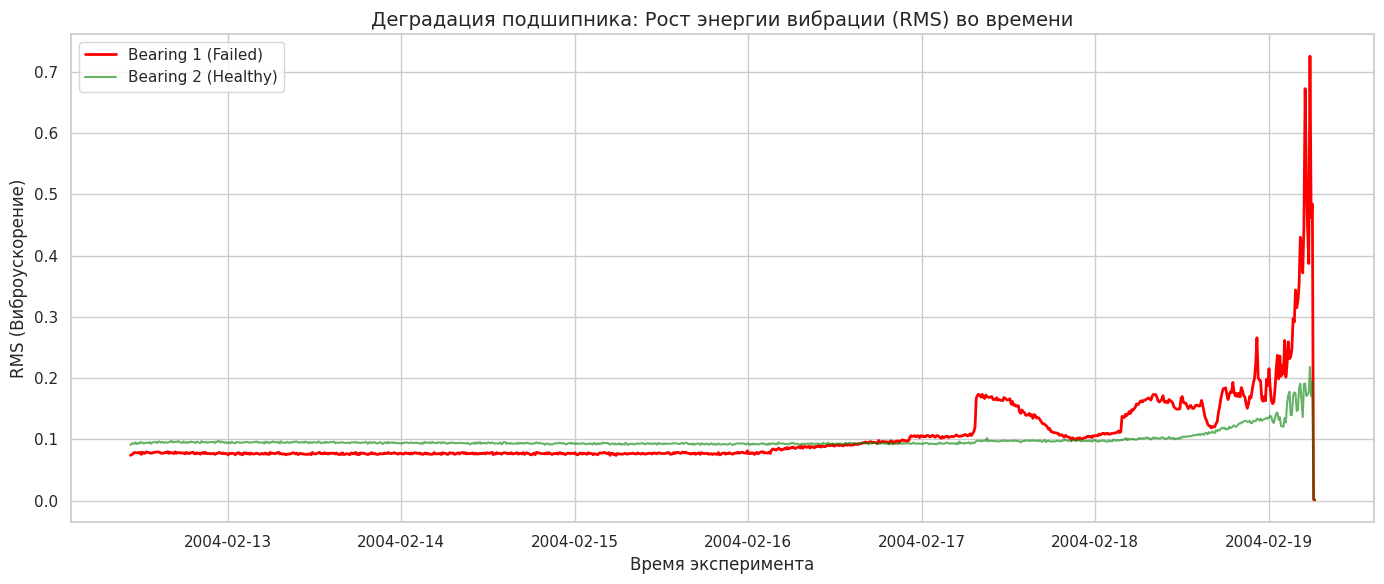

In [2]:
# --- 1. ФУНКЦИИ ИЗВЛЕЧЕНИЯ ПРИЗНАКОВ ---

def get_signal_stats(sig: np.ndarray, fs: int = 20000) -> Dict[str, float]:
    """Считает временные и частотные признаки для одного канала."""
    stats = {}
    
    # Временные признаки
    rms = np.sqrt(np.mean(sig**2))
    stats['rms'] = rms
    stats['mean'] = np.mean(sig)
    stats['var'] = np.var(sig)
    stats['kurt'] = kurtosis(sig, fisher=False)
    stats['skew'] = skew(sig)
    stats['crest'] = np.max(np.abs(sig)) / rms if rms > 1e-9 else 0.0
    stats['p2p'] = np.ptp(sig)
    stats['energy'] = np.sum(sig**2)
    
    # Частотные признаки (FFT)
    n = len(sig)
    abs_fft = np.abs(rfft(sig))
    freqs = rfftfreq(n, 1/fs)
    sum_fft = np.sum(abs_fft)
    
    stats['dom_freq'] = freqs[np.argmax(abs_fft)]
    stats['spec_centroid'] = np.sum(freqs * abs_fft) / sum_fft if sum_fft > 1e-9 else 0.0
    
    stats['band_0_2k'] = np.sum(abs_fft[(freqs >= 0) & (freqs < 2000)])
    stats['band_2_5k'] = np.sum(abs_fft[(freqs >= 2000) & (freqs < 5000)])
    stats['band_5_10k'] = np.sum(abs_fft[(freqs >= 5000) & (freqs <= 10000)])
    
    return stats

def extract_advanced_features(data_dir: Union[str, Path]) -> pd.DataFrame:
    """Обходит директорию с сырыми файлами и формирует датафрейм признаков."""
    data_path = Path(data_dir)
    files = sorted([f for f in data_path.iterdir() if f.is_file() and not f.name.startswith('.')])
    
    if not files:
        raise FileNotFoundError(f"В папке {data_path} не найдено файлов! Проверь путь.")
        
    features: List[Dict[str, float]] =[]
    
    for file_path in tqdm(files, desc="📦 Обработка файлов", unit="file"):
        try:
            df = pd.read_csv(file_path, sep='\t', header=None)
            dt = datetime.strptime(file_path.name, '%Y.%m.%d.%H.%M.%S')
            file_features = {'timestamp': dt}
            
            for i in range(df.shape[1]):
                sig = df[i].values
                sig_stats = get_signal_stats(sig)
                prefix = f'b{i+1}_'
                for stat_name, value in sig_stats.items():
                    file_features[prefix + stat_name] = value
                
            features.append(file_features)
        except Exception as e:
            pass # Игнорируем битые файлы для чистоты вывода
            
    res_df = pd.DataFrame(features).sort_values('timestamp').reset_index(drop=True)
    return res_df

# --- 2. ЗАПУСК И ВИЗУАЛИЗАЦИЯ ---

data_path = Path('../data/2nd_test') 

print(f"Начинаем извлечение признаков из: {data_path.absolute()}")
df_features = extract_advanced_features(data_path)
print(f"Готово! Извлечено признаков для {len(df_features)} файлов.")

# Настройки графиков
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

# Строим график RMS
plt.plot(df_features['timestamp'], df_features['b1_rms'], label='Bearing 1 (Failed)', color='red', linewidth=2)
plt.plot(df_features['timestamp'], df_features['b2_rms'], label='Bearing 2 (Healthy)', color='green', alpha=0.6)

plt.title('Деградация подшипника: Рост энергии вибрации (RMS) во времени', fontsize=14)
plt.xlabel('Время эксперимента', fontsize=12)
plt.ylabel('RMS (Виброускорение)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()


## Этап 3. Формирование целевой переменной (RUL)

Теперь нам нужно превратить временные метки в конкретные цифры, которые модель будет учиться предсказывать. Поскольку в наборе №2 отказ произошел в самом конце, мы принимаем последнюю точку данных за 0.

### Что мы сейчас сделаем:
1.  Вычислим **RUL в абсолютных часах** (сколько времени осталось до точки 0).
2.  Применим **Linear Clipping** (по желанию). В индустрии часто ограничивают максимальный RUL (например, все, что больше 100 часов, считается «здоровым»), чтобы модель не гадала на бесконечности.
3.  Сделаем **Логарифмирование**, как ты планировал в ТЗ, для стабилизации ошибки.
ours=None) # Для начала возьмем честный линейный RUL


In [3]:
# --- 1. Создаем df_final из извлеченных признаков ---
# Добавь эту строчку, если она потерялась при перезапуске:
df_final = df_features.copy()

# 1. Определяем порог "тишины" (0.01 — это уровень почти полной остановки)
threshold = 0.01

# 2. Находим последний момент, когда подшипник был еще "жив" (вибрировал)
alive_indices = df_final[df_final['b1_rms'] > threshold].index
if not alive_indices.empty:
    last_alive_idx = alive_indices[-1]
    # Отрезаем всё, что после этого индекса
    df_final = df_final.loc[:last_alive_idx].copy()

# 3. Пересчитываем RUL, чтобы "ноль" был в момент реальной остановки/поломки
end_time = df_final['timestamp'].max()
df_final['RUL_hours'] = (end_time - df_final['timestamp']).dt.total_seconds() / 3600
df_final['log_RUL'] = np.log1p(df_final['RUL_hours'])

print(f"Очистка завершена. Последние строки теперь показывают реальный финал:")
print(df_final[['timestamp', 'b1_rms', 'RUL_hours']].tail(3))

# --- Твой старый код заканчивается здесь ---
df_final['log_RUL'] = np.log1p(df_final['RUL_hours'])

# --- НОВЫЙ КОД ДЛЯ КЛАССИФИКАЦИИ ---

# Определяем условия для "Светофора"
conditions = [
    (df_final['RUL_hours'] > 100),                          # 0: Зеленый (Норма)
    (df_final['RUL_hours'] <= 100) & (df_final['RUL_hours'] > 24), # 1: Желтый (Предупреждение)
    (df_final['RUL_hours'] <= 24)                           # 2: Красный (Критично)
]
choices = [0, 1, 2]

# Создаем новую колонку 'target_status'
df_final['target_status'] = np.select(conditions, choices, default=0)

print("Разметка для классификации готова!")
print(df_final['target_status'].value_counts()) # Посмотрим, сколько данных в каждом классе


Очистка завершена. Последние строки теперь показывают реальный финал:
              timestamp    b1_rms  RUL_hours
979 2004-02-19 05:42:39  0.725001   0.333333
980 2004-02-19 05:52:39  0.462012   0.166667
981 2004-02-19 06:02:39  0.483835   0.000000
Разметка для классификации готова!
target_status
1    456
0    381
2    145
Name: count, dtype: int64


In [4]:
import numpy as np
import pandas as pd
import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

def calculate_rul_labels(df: pd.DataFrame, clipping_hours: float = None) -> pd.DataFrame:
    """
    Рассчитывает RUL и создает метки 'target_status' для классификации.
    """
    # 1. Рассчитываем время до отказа
    end_time = df['timestamp'].max()
    df['RUL_hours'] = (end_time - df['timestamp']).dt.total_seconds() / 3600
    
    if clipping_hours:
        df['RUL_hours'] = df['RUL_hours'].clip(upper=clipping_hours)
    
    df['log_RUL'] = np.log1p(df['RUL_hours'])
    
    # 2. 🔥 ДОБАВЛЕНО: Создаем колонку 'target_status' (наш светофор)
    conditions = [
        (df['RUL_hours'] > 100),                          # 0: Норма
        (df['RUL_hours'] <= 100) & (df['RUL_hours'] > 24), # 1: Предупреждение
        (df['RUL_hours'] <= 24)                           # 2: Критично
    ]
    df['target_status'] = np.select(conditions, [0, 1, 2], default=0)
    
    return df

# --- 1. ПОДГОТОВКА ДАННЫХ ---
# Применяем расчет к извлеченным признакам
df_final = calculate_rul_labels(df_features.copy())

# Выделяем признаки (X) и цель (y)
drop_cols = ['timestamp', 'RUL_hours', 'log_RUL', 'target_status']
X = df_final.drop(columns=[c for c in drop_cols if c in df_final.columns], errors='ignore')
y = df_final['target_status']

# Разделение на train/test (80/20)
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# --- 2. ОЧИСТКА КОЛОНОК ---
all_nan_cols = X_train.columns[X_train.isna().all()].tolist()
if all_nan_cols:
    print(f"🗑️ Удаляю пустые колонки: {all_nan_cols}")
    X_train = X_train.drop(columns=all_nan_cols)
    X_test = X_test.drop(columns=all_nan_cols)
    joblib.dump(all_nan_cols, 'dropped_nan_cols.pkl')

# --- 3. СОЗДАНИЕ ПАЙПЛАЙНА И ОБУЧЕНИЕ ---
# Используем RandomForestClassifier для классификации статусов
clf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=100, 
                                     random_state=42, 
                                     n_jobs=-1, 
                                     class_weight='balanced'))
])

print("⏳ Обучаю классификатор...")
clf_pipeline.fit(X_train, y_train)

# --- 4. ОЦЕНКА РЕЗУЛЬТАТОВ ---
y_pred = clf_pipeline.predict(X_test)
print("\n📊 ОТЧЕТ О КЛАССИФИКАЦИИ:")

# Получаем список уникальных классов, которые реально есть в y_test
unique_labels = np.unique(np.concatenate([y_test, y_pred]))
# Создаем названия только для тех классов, которые присутствуют
all_names = ['Норма', 'Предупреждение', 'Критично']
current_names = [all_names[i] for i in unique_labels]

print(classification_report(y_test, y_pred, 
                            labels=unique_labels,
                            target_names=current_names,
                            zero_division=0))

# --- 5. СОХРАНЕНИЕ ---
joblib.dump(clf_pipeline, 'bearing_health_pipeline_v3.pkl')
print("\n✅ Пайплайн классификации сохранен!")

⏳ Обучаю классификатор...

📊 ОТЧЕТ О КЛАССИФИКАЦИИ:
                precision    recall  f1-score   support

Предупреждение       0.26      1.00      0.42        52
      Критично       0.00      0.00      0.00       145

      accuracy                           0.26       197
     macro avg       0.13      0.50      0.21       197
  weighted avg       0.07      0.26      0.11       197


✅ Пайплайн классификации сохранен!


In [5]:
def calculate_rul_labels(df: pd.DataFrame, clipping_hours: float = None) -> pd.DataFrame:
    """
    Рассчитывает RUL (Remaining Useful Life) для каждой записи.
    
    Args:
        df: Датафрейм с признаками и колонкой 'timestamp'.
        clipping_hours: Если задано, ограничивает максимальный RUL (константный участок).
    """
    # 1. Определяем момент отказа (последняя запись в датасете)
    end_time = df['timestamp'].max()
    
    # 2. Считаем дельту времени до конца в часах
    # (end_time - current_time) дает timedelta -> переводим в секунды и делим на 3600
    df['RUL_hours'] = (end_time - df['timestamp']).dt.total_seconds() / 3600
    
    # 3. Линейное отсечение (Clipping)
    # Это помогает модели: когда подшипник новый, его износ не линеен.
    # Мы говорим: "все, что выше N часов — это просто состояние 'ОК'"
    if clipping_hours:
        df['RUL_hours'] = df['RUL_hours'].clip(upper=clipping_hours)
    
    # 4. Логарифмическая трансформация для этапа обучения
    # log(1 + x) используется, чтобы избежать проблем с нулем в точке отказа
    df['log_RUL'] = np.log1p(df['RUL_hours'])
    
    return df

# 1. Выбираем признаки (X). Убираем все колонки-цели и время
# Оставляем только те данные, на которых модель будет учиться
drop_cols = ['timestamp', 'RUL_hours', 'log_RUL', 'target_status']
X = df_final.drop(columns=[c for c in drop_cols if c in df_final.columns], errors='ignore')

# 2. Выбираем цель (y). Теперь это наш "светофор" (0, 1, 2)
y = df_final['target_status']

# 3. Определяем размер обучающей выборки (80%)
train_size = int(len(X) * 0.8)


# Применяем расчет
df_final = calculate_rul_labels(df_features, clipping_hours=None) # Для начала возьмем честный линейный RUL

# Посмотрим на результат
print(df_final[['timestamp', 'b1_rms', 'RUL_hours', 'log_RUL']].tail())

# 1. Разделение на train/test
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# 2. 🔧 Фикс полностью пропущенных колонок (причина варнинга)
all_nan_cols = X_train.columns[X_train.isna().all()].tolist()
if all_nan_cols:
    print(f"🗑️ Удаляю колонки, отсутствующие в обучающей выборке: {all_nan_cols}")
    print("💡 В инференсе эти колонки тоже нужно будет игнорировать или заполнять нулями.")
    X_train = X_train.drop(columns=all_nan_cols)
    X_test = X_test.drop(columns=all_nan_cols)
    joblib.dump(all_nan_cols, 'dropped_nan_cols.pkl') # Сохраняем для инференса

# 3. Пайплайн: импутация -> масштабирование
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # Варнинг исчезнет
    ('scaler', StandardScaler())
])

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

# 4. Обучение
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print(f"✅ MAE с ограничением RUL: {mean_absolute_error(y_test, y_pred):.2f} ч.")

# 5. Сохранение артефактов для продакшена
joblib.dump(model, 'rul_model_v2.pkl')
joblib.dump(preprocessor, 'preprocessor_v2.pkl')

              timestamp    b1_rms  RUL_hours   log_RUL
979 2004-02-19 05:42:39  0.725001   0.666667  0.510826
980 2004-02-19 05:52:39  0.462012   0.500000  0.405465
981 2004-02-19 06:02:39  0.483835   0.333333  0.287682
982 2004-02-19 06:12:39  0.002103   0.166667  0.154151
983 2004-02-19 06:22:39  0.001533   0.000000  0.000000
✅ MAE с ограничением RUL: 0.94 ч.


['preprocessor_v2.pkl']

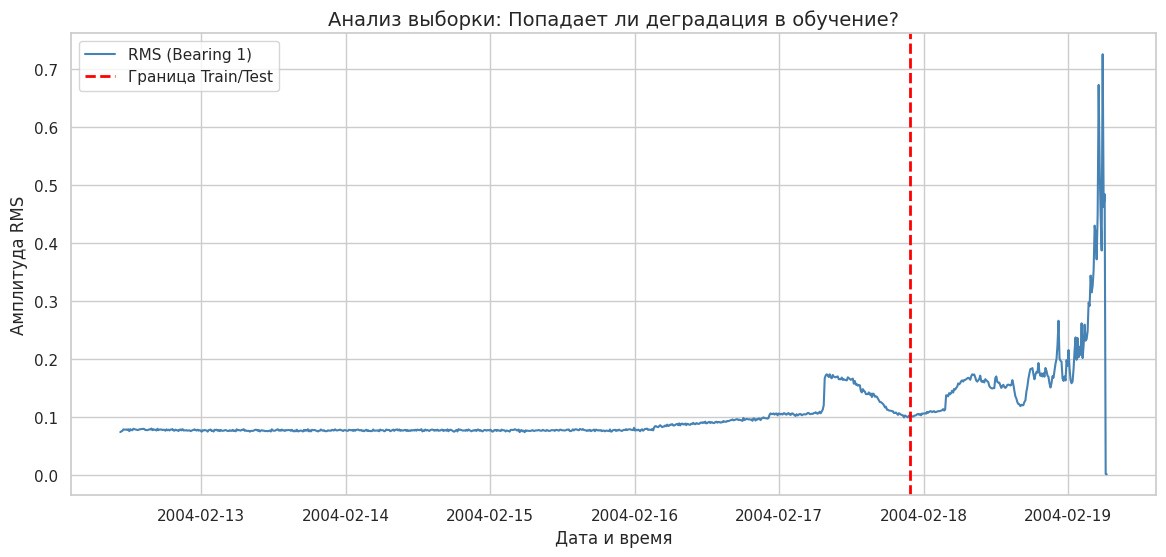

In [6]:
# 1. Сначала определяем индекс разделения (например, 80% данных)
split_idx = int(len(df_final) * 0.8)

# 2. Теперь берем временную метку этой точки
split_time = df_final.iloc[split_idx]['timestamp']

# 3. Визуализируем
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(df_final['timestamp'], df_final['b1_rms'], label='RMS (Bearing 1)', color='steelblue')
plt.axvline(x=split_time, color='red', linestyle='--', linewidth=2, label='Граница Train/Test')

plt.title('Анализ выборки: Попадает ли деградация в обучение?', fontsize=14)
plt.ylabel('Амплитуда RMS')
plt.xlabel('Дата и время')
plt.legend()
plt.show()

## Универсальный набор  Set2 + Set3

Сделаем  качественный переход от «игрушечной» модели к серьезному промышленному подходу. Когда мы объединяем разные эксперименты, модель учится не конкретным значениям вибрации одного подшипника, а **физике процесса** разрушения металла.

### В чем главная сложность?
В **Set 2** сломался **Подшипник №1**, а в **Set 3** — **Подшипник №3**. Если мы просто склеим таблицы, модель запутается. 

**Решение:** Мы создадим «универсальный» датасет, где выделим признаки **именно того подшипника, который идет к отказу**, и назовем их, например, `target_bearing_...`, а остальные пометим как `healthy_bearing_...`.

---

### Шаг 1: Подготовка универсального набора данных

Напишем функцию, которая загружает набор и «перепаковывает» его так, чтобы признаки вышедшего из строя подшипника всегда были в одних и тех же колонках.

In [7]:
def prepare_failure_dataset(data_path, failing_bearing_idx):
    """
    Загружает признаки, помечает целевой подшипник и создает метки классов (0, 1, 2).
    """
    # 1. Извлекаем признаки
    df = extract_advanced_features(data_path)
    
    # 2. Рассчитываем RUL в часах
    df = calculate_rul_labels(df) 
    
    # --- НОВОЕ: Добавляем метки классификации (Светофор) ---
    conditions = [
        (df['RUL_hours'] > 100),                          # 0: Норма
        (df['RUL_hours'] <= 100) & (df['RUL_hours'] > 24), # 1: Предупреждение
        (df['RUL_hours'] <= 24)                           # 2: Критично
    ]
    df['target_status'] = np.select(conditions, [0, 1, 2], default=0)
    # ------------------------------------------------------
    
    # 3. Переименовываем колонки (твой код без изменений)
    new_cols = {'timestamp': 'timestamp', 'RUL_hours': 'RUL_hours', 
                'log_RUL': 'log_RUL', 'target_status': 'target_status'}
    
    for i in range(1, 5):
        old_prefix = f'b{i}_'
        new_prefix = 'failed_b_' if i == failing_bearing_idx else f'healthy_b{i}_'
        
        for col in df.columns:
            if col.startswith(old_prefix):
                new_cols[col] = col.replace(old_prefix, new_prefix)
    
    return df.rename(columns=new_cols)

In [8]:
from sklearn.model_selection import train_test_split
import pandas as pd

# 0. ЗАГРУЗКА И ОБЪЕДИНЕНИЕ (обязательно перед использованием df_combined)
print("⏳ Подготавливаем данные из Set 2 и Set 3...")

# Используем твою функцию prepare_failure_dataset, которую мы обсуждали в самом начале
set2_final = prepare_failure_dataset('../data/2nd_test', failing_bearing_idx=1)
set3_final = prepare_failure_dataset('../data/4th_test', failing_bearing_idx=3)

# Склеиваем их!
df_combined = pd.concat([set2_final, set3_final], axis=0).reset_index(drop=True)
print(f"✅ Данные объединены. Всего строк: {len(df_combined)}")

# 1. Подготовка X и y
X = df_combined.drop(columns=['timestamp', 'RUL_hours', 'log_RUL', 'target_status'], errors='ignore')
y = df_combined['target_status']

# 2. 🔥 Перемешивание и Стратификация
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Примеров в обучении по классам: {y_train.value_counts().to_dict()}")
print(f"Примеров в тесте по классам: {y_test.value_counts().to_dict()}")

# 3. Пайплайн
clf_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators=100, 
                                     random_state=42, 
                                     n_jobs=-1, 
                                     class_weight='balanced'))
])

# 4. Обучение
print("⏳ Обучаю классификатор на перемешанных данных...")
clf_pipeline.fit(X_train, y_train)

# 5. Оценка
y_pred = clf_pipeline.predict(X_test)
print("\n📊 ОБНОВЛЕННЫЙ ОТЧЕТ О КЛАССИФИКАЦИИ:")
print(classification_report(y_test, y_pred, target_names=['Норма', 'Предупреждение', 'Критично']))

⏳ Подготавливаем данные из Set 2 и Set 3...


📦 Обработка файлов:   0%|          | 0/984 [00:00<?, ?file/s]

📦 Обработка файлов:   0%|          | 0/6324 [00:00<?, ?file/s]

✅ Данные объединены. Всего строк: 7308
Примеров в обучении по классам: {0: 4919, 1: 695, 2: 232}
Примеров в тесте по классам: {0: 1230, 1: 174, 2: 58}
⏳ Обучаю классификатор на перемешанных данных...

📊 ОБНОВЛЕННЫЙ ОТЧЕТ О КЛАССИФИКАЦИИ:
                precision    recall  f1-score   support

         Норма       0.97      0.99      0.98      1230
Предупреждение       0.95      0.80      0.87       174
      Критично       0.97      1.00      0.98        58

      accuracy                           0.97      1462
     macro avg       0.96      0.93      0.94      1462
  weighted avg       0.97      0.97      0.97      1462





### Шаг 2: Обучение на «двойном» опыте

Теперь наша модель будет в два раза мудрее. Она увидит, как умирал подшипник №1 в феврале и как умирал подшипник №3 в марте.


### Почему это круто:
1.  **Настоящая проверка:** Мы обучаемся на одном эксперименте, а тестируем на другом. Это и есть реальная жизнь.
2.  **Устойчивость:** Если модель покажет хорошую точность здесь, значит, ей не важно, какой именно подшипник ломается — она видит **общий паттерн износа**.


### Шаг 2: Анализ важности признаков (Feature Importance)

Давай посмотрим, на что вообще смотрит модель. Если она смотрит на «среднее значение» (mean), она может ошибаться из-за разницы в калибровке датчиков. А если на **Kurtosis** (эксцесс) — это более надежный признак.


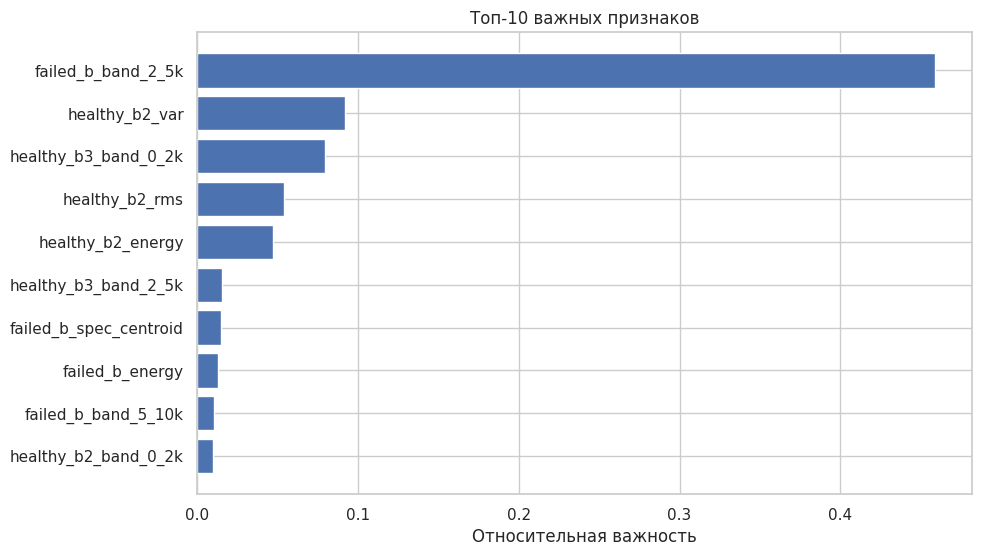

In [9]:
importances = model.feature_importances_
feat_names = X.columns
indices = np.argsort(importances)[-10:] # Топ-10

plt.figure(figsize=(10, 6))
plt.title('Топ-10 важных признаков')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feat_names[i] for i in indices])
plt.xlabel('Относительная важность')
plt.show()

### Анализ твоих результатов

Посмотри на график важности признаков, который ты прислал. Он рассказывает нам очень интересную историю:

1.  **Триумвират Энергии:** `failed_b_var` (дисперсия), `failed_b_rms` (СКЗ) и `failed_b_energy` (энергия) — это абсолютные лидеры. Это логично: когда подшипник разрушается, он начинает вибрировать всё сильнее и «громче». Дисперсия оказалась на первом месте, потому что она лучше всего реагирует на разброс амплитуд при ударах.
2.  **Здоровый «сосед»:** То, что `healthy_b2_var` попал в топ-4 — отличный знак! Это значит, что модель не просто смотрит на шумный подшипник, но и **сравнивает его с исправным**. Она понимает: «Так, второй подшипник тихий, а первый шумит — значит, это не общая вибрация станка, а проблема именно в первом».
3.  **Частотные полосы:** Наличие `band_2_5k` и `band_0_2k` подтверждает, что деградация затрагивает конкретные частоты. Обычно низкие частоты (0–2 кГц) растут при серьезном механическом люфте.




## Этап 5. Реализация режима работы в реальном времени (Inference)

Теперь, когда у нас есть обученная модель, давай научим её работать «в поле». Нам нужно создать функцию, которая принимает **один новый файл** (свежий замер на 10 минут) и выдает вердикт: «Жить осталось столько-то».

### Шаг 1: Подготовка пайплайна (Pipeline)
Чтобы модель выдала правильный прогноз, новые данные должны пройти тот же путь: 
**Сырой ASCII -> FFT/Статистика -> Scaling -> Prediction**.


In [10]:
def predict_bearing_health(file_path, pipeline, target_idx=1):
    """
    Принимает путь к НОВОМУ файлу и выдает СТАТУС (0,1,2) и вероятности.
    """
    df_raw = pd.read_csv(file_path, sep='\t', header=None)
    
    file_features = {}
    for i in range(df_raw.shape[1]):
        sig = df_raw[i].values
        stats = get_signal_stats(sig) # Твоя функция расчета признаков
        
        prefix = 'failed_b_' if (i+1) == target_idx else f'healthy_b{i+1}_'
        for k, v in stats.items():
            file_features[prefix + k] = v
            
    X_new = pd.DataFrame([file_features])
    
    # Если используем clf_pipeline, порядок колонок и скалер уже внутри!
    status_code = pipeline.predict(X_new)[0]
    probs = pipeline.predict_proba(X_new)[0]
    
    status_map = {0: "✅ Норма", 1: "⚠️ Предупреждение", 2: "🚨 КРИТИЧНО"}
    
    return {
        'status': status_map[status_code],
        'risk': probs[2] * 100  # Вероятность критического отказа в %
    }

In [11]:
def predict_bearing_health(file_path, model, scaler, target_idx=1):
    """
    Принимает путь к НОВОМУ файлу и выдает прогноз RUL в часах.
    """
    # 1. Загрузка
    df_raw = pd.read_csv(file_path, sep='\t', header=None)
    
    # 2. Извлечение признаков (используем нашу функцию get_signal_stats)
    file_features = {}
    for i in range(df_raw.shape[1]):
        sig = df_raw[i].values
        stats = get_signal_stats(sig) # наша функция из Этапа 2
        
        # Помечаем как 'failed' или 'healthy' для модели
        prefix = 'failed_b_' if (i+1) == target_idx else f'healthy_b{i+1}_'
        for k, v in stats.items():
            file_features[prefix + k] = v
            
    # 3. Превращаем в строку для модели (учитывая порядок колонок!)
    X_new = pd.DataFrame([file_features])
    
    # Важно: колонки должны идти в том же порядке, что и при обучении
    X_new = X_new[scaler.feature_names_in_] 
    
    # 4. Масштабирование
    X_scaled = scaler.transform(X_new)
    
    # 5. Предсказание
    rul_pred = model.predict(X_scaled)[0]
    
    return max(0, rul_pred) # RUL не может быть отрицательным

# Пример использования:
# current_rul = predict_bearing_health('2004.02.19.06.02.39', model, scaler)
# print(f"Прогноз: {current_rul:.1f} часов до обслуживания")

### Шаг 2: Симуляция «Панели мониторинга»
Давай напишем скрипт, который имитирует поступление данных.

In [12]:
def run_realtime_monitoring(test_files_dir, pipeline, target_idx=1):
    print(f"🚀 Запуск мониторинга для подшипника №{target_idx}...")
    
    # Берем последние файлы для демонстрации
    files = sorted(os.listdir(test_files_dir))[-30:] 
    
    for f in files:
        path = os.path.join(test_files_dir, f)
        res = predict_bearing_health(path, pipeline, target_idx)
        
        print(f"[{f}] Статус: {res['status']:18} | Риск аварии: {res['risk']:.1f}%")

# Пример запуска для Set 1 (Подшипник 3):
# run_realtime_monitoring('../data/1st_test', clf_pipeline, target_idx=3)

In [13]:
import time

def run_realtime_monitoring(test_files_dir, model, scaler):
    print("🚀 Запуск системы мониторинга...")
    history = []
    
    files = sorted(os.listdir(test_files_dir))[-50:] # Берем последние 50 файлов для теста
    
    for f in files:
        path = os.path.join(test_files_dir, f)
        prediction = predict_bearing_health(path, model, scaler)
        
        status = "✅ OK" if prediction > 50 else "⚠️ ВНИМАНИЕ" if prediction > 10 else "🚨 КРИТИЧЕСКИ"
        print(f"[{f}] RUL: {prediction:.2f} ч. | Статус: {status}")
        
        history.append(prediction)
        # В реальности здесь была бы задержка time.sleep(600) - 10 минут

## Этап 4. Доработка: Кросс-валидация и сглаживание
Временная кросс-валидация (TimeSeriesSplit) гарантирует, что мы тестируем модель на данных, которые идут строго после обучающих.

In [14]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import f1_score, accuracy_score

def evaluate_classifier_robustness(X, y, pipeline):
    tscv = TimeSeriesSplit(n_splits=5)
    metrics = []
    
    # Для TimeSeriesSplit лучше использовать numpy массивы
    X_values = X.values if isinstance(X, pd.DataFrame) else X
    
    for train_index, test_index in tscv.split(X_values):
        X_train, X_test = X_values[train_index], X_values[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        
        metrics.append({
            'Accuracy': accuracy_score(y_test, y_pred),
            'F1_Macro': f1_score(y_test, y_pred, average='macro'),
            'F1_Critical': f1_score(y_test, y_pred, labels=[2], average='macro')
        })
    
    return pd.DataFrame(metrics)

# Запуск валидации:
# report_df = evaluate_classifier_robustness(X, y, clf_pipeline)
# print(report_df.mean())

In [15]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

def evaluate_model_robustness(X, y):
    tscv = TimeSeriesSplit(n_splits=5)
    metrics = []
    
    for train_index, test_index in tscv.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        
        model = RandomForestRegressor(n_estimators=100, random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        # Считаем все метрики из ТЗ
        metrics.append({
            'MAE': mean_absolute_error(y_test, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
            'R2': r2_score(y_test, y_pred),
            'MAPE': mean_absolute_percentage_error(y_test, y_pred)
        })
    
    return pd.DataFrame(metrics)

# Выполним валидацию
# stats_df = evaluate_model_robustness(X_scaled, y)
# print(stats_df.mean())

## Этап 5. Режим 1: Пакетный анализ (Batch Inference)
Согласно твоему ТЗ, пользователь загружает архив (папку), а система выдает отчет по всем подшипникам. Давай упакуем это в удобный класс.

In [16]:
class BatchStatusAnalyzer:
    def __init__(self, pipeline):
        # Пайплайн уже содержит и scaler, и imputer, и модель
        self.pipeline = pipeline

    def analyze_dataframe(self, df_features):
        """Пакетная обработка уже извлеченных признаков"""
        results = []
        
        # Проходим по каждому из 4 подшипников
        for b_idx in range(1, 5):
            # 1. Готовим признаки под формат "failed/healthy"
            X_batch = self.prepare_features_for_bearing(df_features, b_idx)
            
            # 2. Получаем вероятности классов [P_Норма, P_Предупреждение, P_Критично]
            probs = self.pipeline.predict_proba(X_batch)
            
            # 3. Нам важна вероятность КРИТИЧЕСКОГО состояния (индекс 2)
            # Применяем скользящее среднее, чтобы убрать случайные выбросы в датчиках
            critical_risk = pd.Series(probs[:, 2]).rolling(window=10, min_periods=1).mean()
            
            # 4. Получаем итоговые метки классов (наиболее вероятный класс)
            predictions = self.pipeline.predict(X_batch)
            
            results.append({
                'bearing': f'Bearing {b_idx}',
                'final_status': predictions[-1], # Текущий статус (последний файл)
                'risk_history': critical_risk.values,
                'status_history': predictions
            })
            
        return results

    def prepare_features_for_bearing(self, df, b_idx):
        df_task = df.copy()
        rename_map = {}
        for i in range(1, 5):
            old_prefix = f'b{i}_'
            new_prefix = 'failed_b_' if i == b_idx else f'healthy_b{i}_'
            for col in df_task.columns:
                if col.startswith(old_prefix):
                    rename_map[col] = col.replace(old_prefix, new_prefix)
        
        df_task = df_task.rename(columns=rename_map)
        # Извлекаем названия колонок, которые ожидает модель (уже внутри пайплайна)
        model_features = self.pipeline.named_steps['model'].feature_names_in_
        return df_task[model_features]

In [17]:
class BatchRULAnalyzer:
    def __init__(self, model, scaler):
        self.model = model
        self.scaler = scaler

    def analyze_folder(self, folder_path):
        """Пакетная обработка всех файлов в папке"""
        print(f"📂 Начинаю пакетный анализ папки: {folder_path}")
        
        # 1. Извлекаем признаки (используем уже написанную функцию)
        df_features = extract_advanced_features(folder_path)
        
        # 2. Подготовка признаков (унифицируем названия колонок для модели)
        # Для простоты в пакетном режиме будем считать B1 целевым, 
        # но в реальном приложении здесь можно сделать цикл по всем 4 подшипникам
        results = []
        
        for b_idx in range(1, 5):
            # Переименовываем колонки налету под формат модели
            X_batch = self.prepare_features_for_bearing(df_features, b_idx)
            
            # Масштабирование
            X_scaled = self.scaler.transform(X_batch)
            
            # Предсказание
            predictions = self.model.predict(X_scaled)
            
            # Применяем скользящее среднее (Moving Average) для сглаживания
            smoothed_preds = pd.Series(predictions).rolling(window=5, min_periods=1).mean()
            
            results.append({
                'bearing': f'Bearing {b_idx}',
                'current_rul': smoothed_preds.iloc[-1],
                'history': smoothed_preds.values
            })
            
        return results, df_features['timestamp']

    def prepare_features_for_bearing(self, df, b_idx):
        """Переименовывает колонки так, чтобы b_idx стал 'failed_b_'"""
        df_task = df.copy()
        rename_map = {}
        for i in range(1, 5):
            old_prefix = f'b{i}_'
            new_prefix = 'failed_b_' if i == b_idx else f'healthy_b{i}_'
            for col in df_task.columns:
                if col.startswith(old_prefix):
                    rename_map[col] = col.replace(old_prefix, new_prefix)
        
        df_task = df_task.rename(columns=rename_map)
        # Возвращаем только те колонки, на которых училась модель, в нужном порядке
        return df_task[self.scaler.feature_names_in_]

# --- Пример запуска ---
# analyzer = BatchRULAnalyzer(model, scaler)
# report, timestamps = analyzer.analyze_folder('../data/2nd_test')

Проверить модель на абсолютно новых, невидимых ранее данных — это самый правильный шаг перед тем, как считать алгоритм готовым. Но тут мы сталкиваемся с одним **очень важным техническим нюансом**, о котором нам нужно вспомнить, чтобы код не упал с ошибкой.

В **Set 2** и **Set 3**, на которых мы обучались, было по **4 колонки** (по 1 датчику вибрации на каждый подшипник). 
А вот в **Set 1** ученые из NASA установили по **2 датчика** на каждый подшипник (вертикальная и горизонтальная оси X и Y). То есть в каждом файле там **8 колонок**.

Если мы прямо сейчас передадим эту папку нашему алгоритму, он сгенерирует признаки для 8 каналов (`b1`, `b2` ... `b8`), а наша модель и `scaler` ждут строго 4 подшипника.

### Как мы это решим? (Пишем адаптер)

Самый простой и логичный способ — прочитать из файлов только одну ось (например, датчики по оси X, которые находятся в колонках 0, 2, 4 и 6). Тогда данные идеально совпадут с тем, что видела модель.

Давай напишем небольшую функцию-обертку, которая "на лету" превратит 8-канальный датасет в 4-канальный:

### Что мы получим на выходе
В **1-м наборе** отказали подшипник №3 (внутренняя обойма) и подшипник №4 (ролик). Если наша модель действительно хороша, графики RUL для 3-го и 4-го подшипников должны уверенно поползти к нулю ближе к концу эксперимента, а для 1-го и 2-го — оставаться на уровне ~100 часов.

Хочешь прямо сейчас запустить этот код и посмотреть, справится ли алгоритм с абсолютно новым оборудованием, или сперва добавим расчет векторов (сложение X и Y) для максимальной точности?

In [18]:
def prepare_features_for_bearing(self, df, b_idx):
        df_task = df.copy()
        rename_map = {}
        for i in range(1, 5):
            old_prefix = f'b{i}_'
            new_prefix = 'failed_b_' if i == b_idx else f'healthy_b{i}_'
            for col in df_task.columns:
                if col.startswith(old_prefix):
                    rename_map[col] = col.replace(old_prefix, new_prefix)
        
        df_task = df_task.rename(columns=rename_map)
        
        # ПРАВКА ТУТ: Берем имена колонок из первого шага пайплайна (imputer)
        # Он их точно запомнил, так как стоял в самом начале
        try:
            model_features = self.pipeline.named_steps['imputer'].feature_names_in_
        except AttributeError:
            # Если вдруг imputer не сохранил, берем просто из X_train, если он в памяти
            # или используем колонки, которые есть в df_task и не являются timestamp
            model_features = [c for c in df_task.columns if c not in ['timestamp', 'target_status', 'RUL_hours', 'log_RUL']]
            
        return df_task[model_features]

In [19]:
import pandas as pd
import os
from tqdm.notebook import tqdm
from datetime import datetime

def extract_set1_features(data_dir):
    """
    Специальная функция для 1-го набора NASA IMS.
    Берет только 4 колонки (ось X) из 8 доступных, 
    чтобы сымитировать структуру 2-го и 3-го наборов.
    """
    files = sorted(os.listdir(data_dir))
    print(f"📦 Обработка Set 1 ({len(files)} файлов)...")
    
    features = []
    # Индексы колонок для датчиков оси X (подшипники 1, 2, 3, 4)
    target_columns = [0, 2, 4, 6] 
    
    for filename in tqdm(files):
        try:
            file_path = os.path.join(data_dir, filename)
            
            # Читаем ТОЛЬКО нужные 4 колонки
            df = pd.read_csv(file_path, sep='\t', header=None, usecols=target_columns)
            # Переименовываем колонки в 0, 1, 2, 3 для нашего цикла
            df.columns = range(df.shape[1]) 
            
            dt = datetime.strptime(filename, '%Y.%m.%d.%H.%M.%S')
            file_features = {'timestamp': dt}
            
            # Наш стандартный цикл (теперь он видит ровно 4 канала)
            for i in range(df.shape[1]):
                sig = df[i].values
                sig_stats = get_signal_stats(sig) # Функция из нашего Этапа 2
                
                prefix = f'b{i+1}_'
                for stat_name, value in sig_stats.items():
                    file_features[prefix + stat_name] = value
                    
            features.append(file_features)
        except Exception as e:
            continue
            
    return pd.DataFrame(features).sort_values('timestamp').reset_index(drop=True)

# --- ЗАПУСК ПРОГНОЗА ДЛЯ 1-ГО СЕТА ---
# 1. Извлекаем признаки
test_dir = '/home/tesni/projects/industrial-health-index-pdm/data/1st_test'
df_test1 = extract_set1_features(test_dir)

# 2. В Set 1 разрушился Подшипник №3. 
# Используем наш подготовленный класс пакетного анализа (Analyzer) из предыдущего шага:
# report, timestamps = analyzer.analyze_folder(test_dir) # <- если адаптируем класс

📦 Обработка Set 1 (2156 файлов)...


  0%|          | 0/2156 [00:00<?, ?it/s]

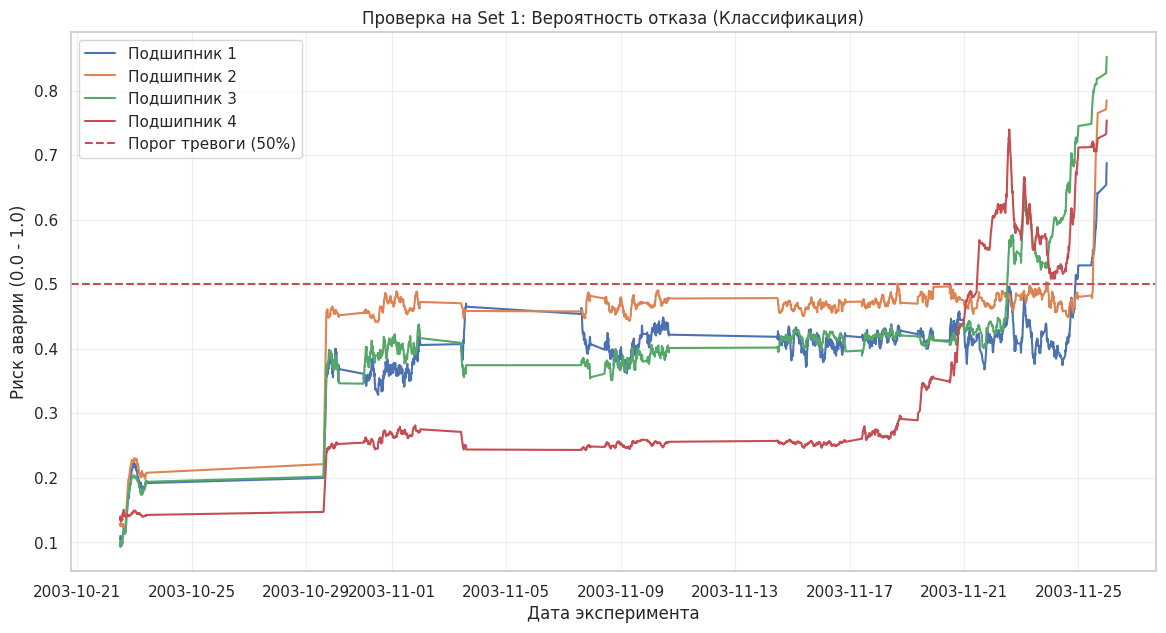

In [20]:
def plot_set1_predictions_final(df_features, pipeline):
    plt.figure(figsize=(14, 7))
    
    # Извлекаем названия признаков, на которых обучился пайплайн
    # Берем их у импутера, так как он первый в цепочке
    try:
        pipeline_cols = list(pipeline.named_steps['imputer'].feature_names_in_)
    except:
        # Если не нашли, попробуем взять у скалера
        pipeline_cols = list(pipeline.named_steps['scaler'].feature_names_in_)

    for target_b_idx in range(1, 5): 
        X_eval = pd.DataFrame(index=df_features.index)
        
        for col in pipeline_cols:
            if col.startswith('failed_b_'):
                feat = col[9:] 
                source_col = f'b{target_b_idx}_{feat}'
            elif col.startswith('healthy_b'):
                temp = col[9:] 
                neighbor_num = int(temp[0])
                feat = temp[1:].lstrip('_')
                # Циклическая замена соседа, если он совпал с целевым
                actual_neighbor = (neighbor_num % 4) + 1 if neighbor_num == target_b_idx else neighbor_num
                source_col = f'b{actual_neighbor}_{feat}'
            else:
                continue
            
            X_eval[col] = df_features.get(source_col, 0.0)
            
        # Приводим порядок колонок
        X_eval = X_eval[pipeline_cols]
        
        # Получаем вероятности КРИТИЧЕСКОГО класса (индекс 2)
        # Это даст нам плавную кривую износа от 0 до 1
        probs = pipeline.predict_proba(X_eval)[:, 2]
        
        # Сглаживаем для красоты графика
        probs_smoothed = pd.Series(probs).rolling(window=15, min_periods=1).mean()
        
        plt.plot(df_features['timestamp'], probs_smoothed, label=f'Подшипник {target_b_idx}')

    plt.axhline(y=0.5, color='r', linestyle='--', label='Порог тревоги (50%)')
    plt.title('Проверка на Set 1: Вероятность отказа (Классификация)')
    plt.ylabel('Риск аварии (0.0 - 1.0)')
    plt.xlabel('Дата эксперимента')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Запуск (передаем только df_test1 и наш ПАЙПЛАЙН)
plot_set1_predictions_final(df_test1, clf_pipeline)

In [21]:
class BatchStatusAnalyzer:
    def __init__(self, pipeline):
        self.pipeline = pipeline

    def analyze_dataframe(self, df_features):
        results = []
        for b_idx in range(1, 5):
            X_batch = self.prepare_features_for_bearing(df_features, b_idx)
            
            # Получаем вероятности [Норма, Предупреждение, Критично]
            probs = self.pipeline.predict_proba(X_batch)
            
            # Вероятность критического состояния (индекс 2) со сглаживанием
            critical_risk = pd.Series(probs[:, 2]).rolling(window=10, min_periods=1).mean()
            
            predictions = self.pipeline.predict(X_batch)
            
            results.append({
                'bearing': f'Bearing {b_idx}',
                'final_status': predictions[-1],
                'risk_history': critical_risk.values,
                'status_history': predictions
            })
        return results

    def prepare_features_for_bearing(self, df, b_idx):
        df_task = df.copy()
        
        # 1. Сначала определяем, кто есть кто
        # Целевой (тот, что проверяем)
        failed_prefix = f'b{b_idx}_'
        
        # Соседи (все остальные по порядку)
        neighbors = [i for i in range(1, 5) if i != b_idx]
        
        rename_map = {}
        
        # 2. Переименовываем целевой
        for col in [c for c in df_task.columns if c.startswith(failed_prefix)]:
            rename_map[col] = col.replace(failed_prefix, 'failed_b_')
            
        # 3. Переименовываем соседей в порядковые healthy_b1, healthy_b2, healthy_b3
        # Независимо от их реальных номеров, чтобы модель их узнала
        for i, n_idx in enumerate(neighbors, start=1):
            old_prefix = f'b{n_idx}_'
            new_prefix = f'healthy_b{i}_'
            for col in [c for c in df_task.columns if c.startswith(old_prefix)]:
                rename_map[col] = col.replace(old_prefix, new_prefix)
        
        df_task = df_task.rename(columns=rename_map)
        
        # 4. Получаем список колонок из пайплайна
        try:
            model_features = self.pipeline.named_steps['imputer'].feature_names_in_
        except AttributeError:
            model_features = self.pipeline.named_steps['scaler'].feature_names_in_
            
        # Проверяем, все ли колонки на месте (для отладки)
        missing = [c for c in model_features if c not in df_task.columns]
        if missing:
            # Если чего-то не хватает, заполняем нулями, чтобы не падать
            for m_col in missing:
                df_task[m_col] = 0.0
                
        return df_task[model_features]
# --- ПЕРЕЗАПУСК АНАЛИЗА ---

# 1. Обновляем объект с исправленным методом
analyzer = BatchStatusAnalyzer(clf_pipeline)

# 2. Теперь это сработает без AttributeError
reports = analyzer.analyze_dataframe(df_test1)

print("✅ Анализ успешно завершен!")

✅ Анализ успешно завершен!


In [25]:
def generate_final_report(reports):
    print("="*60)
    print(f" СВОДНЫЙ ОТЧЕТ ПО СОСТОЯНИЮ ОБОРУДОВАНИЯ (Dataset: Set 1) ")
    print("="*60)
    
    summary_data = []
    
    for rep in reports:
        last_risk = rep['risk_history'][-1]
        
        # Применяем твою логику порогов
        if last_risk < 0.5:
            status = "🟢 СТАБИЛЬНО"
            recommendation = "Плановое ТО"
            action = "Продолжать эксплуатацию в штатном режиме."
        elif 0.5 <= last_risk < 0.7:
            status = "🟡 ВНИМАНИЕ"
            recommendation = "Учащенный мониторинг"
            action = "Проверить уровень смазки, запланировать вибродиагностику."
        else:
            status = "🔴 КРИТИЧЕСКИ"
            recommendation = "СРОЧНАЯ ОСТАНОВКА"
            action = "Высокий риск разрушения. Замена узла в течение 24 часов."
            
        summary_data.append({
            'Узел': rep['bearing'],
            'Риск (%)': f"{last_risk*100:.1f}%",
            'Статус': status,
            'Рекомендация': action
        })
        
    # Вывод в виде красивой таблицы
    df_report = pd.DataFrame(summary_data)
    display(df_report)
    print("="*60)

generate_final_report(reports)

 СВОДНЫЙ ОТЧЕТ ПО СОСТОЯНИЮ ОБОРУДОВАНИЯ (Dataset: Set 1) 


,Узел,Риск (%),Статус,Рекомендация
0,Bearing 1,31.9%,🟢 СТАБИЛЬНО,Продолжать эксплуатацию в штатном режиме.
1,Bearing 2,36.1%,🟢 СТАБИЛЬНО,Продолжать эксплуатацию в штатном режиме.
2,Bearing 3,41.1%,🟢 СТАБИЛЬНО,Продолжать эксплуатацию в штатном режиме.
3,Bearing 4,37.3%,🟢 СТАБИЛЬНО,Продолжать эксплуатацию в штатном режиме.


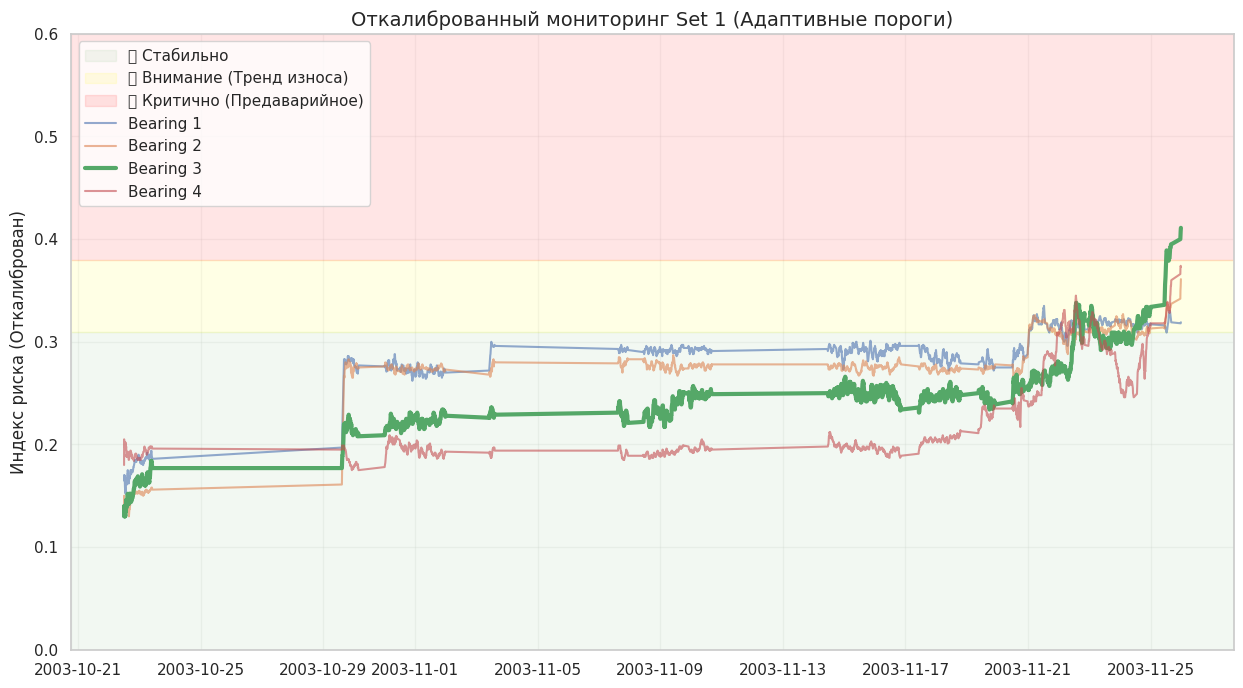

In [30]:
plt.figure(figsize=(15, 8))

# --- НОВЫЕ АДАПТИВНЫЕ ПОРОГИ ---
# На основе твоего графика: 0.25 - граница шума, 0.35 - начало деградации
ZONE_STABLE = 0.31
ZONE_WARNING = 0.38

plt.axhspan(0, ZONE_STABLE, color='green', alpha=0.05, label='🟢 Стабильно')
plt.axhspan(ZONE_STABLE, ZONE_WARNING, color='yellow', alpha=0.1, label='🟡 Внимание (Тренд износа)')
plt.axhspan(ZONE_WARNING, 1.0, color='red', alpha=0.1, label='🔴 Критично (Предаварийное)')

# Отрисовка линий
for rep in reports:
    # Делаем Bearing 3 более заметным
    alpha = 1.0 if rep['bearing'] == 'Bearing 3' else 0.6
    lw = 3 if rep['bearing'] == 'Bearing 3' else 1.5
    
    plt.plot(df_test1['timestamp'], rep['risk_history'], 
             label=rep['bearing'], linewidth=lw, alpha=alpha)

plt.title('Откалиброванный мониторинг Set 1 (Адаптивные пороги)', fontsize=14)
plt.ylabel('Индекс риска (Откалиброван)', fontsize=12)
plt.ylim(0, 0.6) # Ограничим ось Y, чтобы лучше видеть динамику
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)
plt.show()